In [224]:

import func

import numpy as np
import matplotlib.pyplot as plt
import math

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def gaussian(r, sigma, D):
    if r < D:
        return np.exp(- r**2 / (2 * sigma**2))
    else:
        return 0

def cubic_bspline(r, sigma, D):
    q = r / sigma

    if q < (D / 2):
        return (2/3) - 4*q**2 + 4*q**3

    elif q < D:
        return (4/3) * (1-q)**3

    else:
        return 0

def calculate_vector_field(scan_points, scan_normals, grid_points, sigma, cuttoff_distance):
    
    V = np.zeros((len(grid_points), 2))

    for i, x in enumerate(grid_points):
        for p, n in zip(scan_points, scan_normals):
            r = func.distance(x, p)

            weight = gaussian(r, sigma, cuttoff_distance)
            """ weight = cubic_bspline(r, sigma, cuttoff_distance) """

            V[i] += weight * np.asarray(n)

    return V

# First Order Finite difference
def calculate_gradient(Vx, Vy, dx, dy):

    # First-order finite difference
    dVx_dx = np.zeros_like(Vx)
    dVy_dy = np.zeros_like(Vy)

    # dVx/dx
    dVx_dx[:-1, :] = (Vx[1:, :] - Vx[:-1, :]) / dx
    dVx_dx[-1, :] = (Vx[-1, :] - Vx[-2, :]) / dx

    # dVy/dy
    dVy_dy[:, :-1] = (Vy[:, 1:] - Vy[:, :-1]) / dy
    dVy_dy[:, -1] = (Vy[:, -1] - Vy[:, -2]) / dy

    return dVx_dx, dVy_dy

def calculate_divergence(grid_vectors, nx, ny, dx, dy):

    Vx = grid_vectors[:, 0].reshape(nx, ny)
    Vy = grid_vectors[:, 1].reshape(nx, ny)
    
    dVx_dx = np.gradient(Vx, dx, axis=0)
    dVy_dy = np.gradient(Vy, dy, axis=1)

    """ dVx_dx, dVy_dy = calculate_gradient(Vx, Vy, dx, dy) """

    divergence = dVx_dx + dVy_dy

    return divergence.ravel()


def poisson_solver(divergence, nx, ny, dx, dy):

    divergence_grid = divergence.reshape(nx, ny)

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)

    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    laplacian_eigenvalues = -(KX**2 + KY**2)

    divergence_hat = np.fft.fft2(divergence_grid)

    chi_hat = np.zeros_like(divergence_hat, dtype=complex)

    mask = laplacian_eigenvalues != 0

    chi_hat[mask] = ( divergence_hat[mask] / laplacian_eigenvalues[mask] )

    chi_hat[0, 0] = 0

    chi_grid = np.real(np.fft.ifft2(chi_hat))

    return chi_grid.ravel()


def poisson_solver_dirch(divergence, nx, ny, dx, dy, boundary_value = 1):

    divergence_grid = divergence.reshape(nx, ny)

    N = nx * ny

    A = lil_matrix((N, N))
    b = np.zeros(N)

    def idx(i, j):
        return i * ny + j

    for i in range(nx):
        for j in range(ny):

            k = idx(i, j)

            # Dirichlet boundary conditions:
            # chi = 1 on the boundary
            if i == 0 or i == nx - 1 or j == 0 or j == ny - 1:

                A[k, k] = 1.0
                b[k] = boundary_value

            else:

                A[k, k] = (
                    2.0 / dx**2 +
                    2.0 / dy**2
                )

                A[k, idx(i + 1, j)] = -1.0 / dx**2
                A[k, idx(i - 1, j)] = -1.0 / dx**2

                A[k, idx(i, j + 1)] = -1.0 / dy**2
                A[k, idx(i, j - 1)] = -1.0 / dy**2

                b[k] = divergence_grid[i, j]

    chi_grid = spsolve(A.tocsr(), b)

    return chi_grid


$$
f(r) = \exp\left(\frac{r^2}{2\sigma^2}\right)
$$

$$
\nabla \cdot \mathbf{v} = \nabla^2 \mathbf{X}
$$

$$
\nabla \cdot \mathbf{v} \approx y
$$

In [232]:



def generate_circle_points(n=25):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    points = np.column_stack((np.cos(angles), np.sin(angles)))
    normals = points.copy()

    return points, normals

def generate_square_points(n_per_side=25, size=1.0):
    scan_points = []
    scan_normals = []

    for x in np.linspace(-size, size, n_per_side, endpoint=False):
        scan_points.append([x, -size])
        scan_normals.append([0, -1])

    for y in np.linspace(-size, size, n_per_side, endpoint=False):
        scan_points.append([size, y])
        scan_normals.append([1, 0])

    for x in np.linspace(size, -size, n_per_side, endpoint=False):
        scan_points.append([x, size])
        scan_normals.append([0, 1])

    for y in np.linspace(size, -size, n_per_side, endpoint=False):
        scan_points.append([-size, y])
        scan_normals.append([-1, 0])

    scan_points = np.array(scan_points, dtype=float)
    scan_normals = np.array(scan_normals, dtype=float)

    return scan_points, scan_normals


scan_points, scan_normals = generate_circle_points(100)


size = 2

""" del_space = 1
nx = int(size * 2 / del_space) + 1
ny = int(size * 2 / del_space) + 1 """

nx = 100
ny = 100

x = np.linspace(-size, size, nx)
y = np.linspace(-size, size, ny)

dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="ij")

grid_points = np.column_stack( (X.ravel(), Y.ravel()) )

sigma = 0.46

D = 1

grid_vectors = calculate_vector_field(scan_points, scan_normals, grid_points, sigma, D)

divergence = calculate_divergence(grid_vectors, nx, ny, dx, dy)

chi = poisson_solver(divergence, nx, ny, dx, dy)
""" chi = poisson_solver_dirch(divergence, nx, ny, dx, dy) """

chi_grid = chi.reshape(nx, ny)


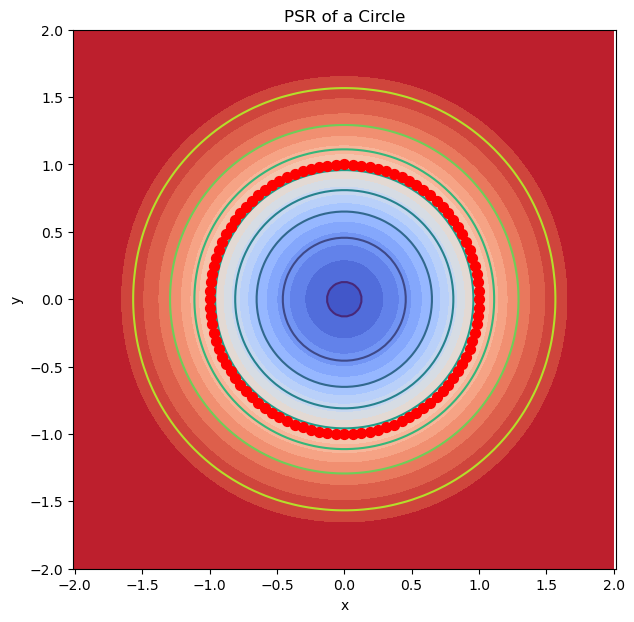

In [233]:
from scipy.interpolate import RegularGridInterpolator

interpolator = RegularGridInterpolator((x, y), chi_grid)

chi_samples = interpolator(scan_points)

iso_value = np.mean(chi_samples)

plt.figure(figsize=(7, 7))

plt.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value],
    colors="blue"
)

plt.scatter(
    scan_points[:, 0],
    scan_points[:, 1],
    color="red",
    s=50,
    zorder=3
)

#plt.quiver(
#    scan_points[:, 0],
#    scan_points[:, 1],
#    scan_normals[:, 0],
#    scan_normals[:, 1],
#    color="black",
#    angles="xy",
#    scale_units="xy",
#    scale=1,
#    width=0.005,
#    zorder=4
#)

plt.contourf(X, Y, chi_grid, cmap="coolwarm", levels=20)
plt.contour(X, Y, chi_grid)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PSR of a Circle")

plt.show()



MAE       : 0.0007004389468968796
RMSE      : 0.0009935298600766502
Max error : 0.0029237140175177867


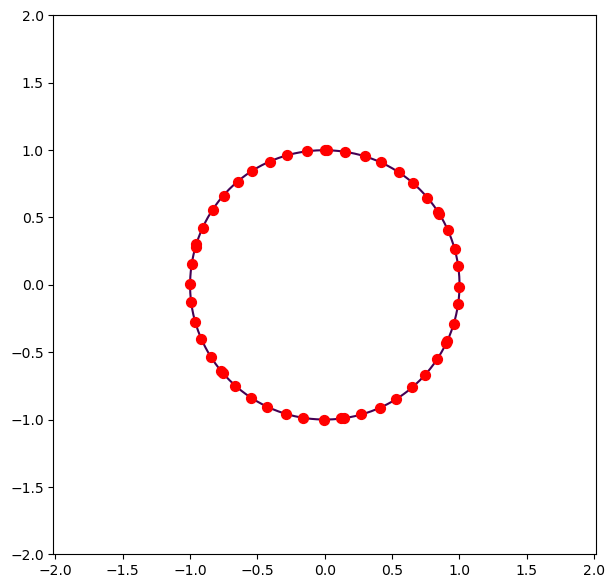

In [219]:

def calculate_rmse(reconstructed_points):

    radii = np.sqrt(
        reconstructed_points[:, 0]**2 +
        reconstructed_points[:, 1]**2
    )

    errors = radii - 1.0
    rmse = np.sqrt(np.mean(errors**2))

    return rmse

fig, ax = plt.subplots(figsize=(7, 7))


contour = ax.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value]
)

reconstructed_points = contour.allsegs[0][0]

r = np.sqrt(
    reconstructed_points[:, 0]**2 +
    reconstructed_points[:, 1]**2
)

errors = np.abs(r - 1.0)

# Error metrics
mae = np.mean(errors)
rmse = np.sqrt(np.mean(errors**2))
max_error = np.max(errors)

print("MAE       :", mae)
print("RMSE      :", rmse)
print("Max error :", max_error)

ax.scatter(
    scan_points[:, 0],
    scan_points[:, 1],
    color="red",
    s=50,
    zorder=3
)

ax.axis("equal")
plt.show()

sigma = 0.300, RMSE = 0.001560
sigma = 0.316, RMSE = 0.001486
sigma = 0.332, RMSE = 0.001407
sigma = 0.347, RMSE = 0.001326
sigma = 0.363, RMSE = 0.001248
sigma = 0.379, RMSE = 0.001177
sigma = 0.395, RMSE = 0.001114
sigma = 0.411, RMSE = 0.001063
sigma = 0.426, RMSE = 0.001026
sigma = 0.442, RMSE = 0.001003
sigma = 0.458, RMSE = 0.000994
sigma = 0.474, RMSE = 0.000998
sigma = 0.489, RMSE = 0.001013
sigma = 0.505, RMSE = 0.001039
sigma = 0.521, RMSE = 0.001072
sigma = 0.537, RMSE = 0.001110
sigma = 0.553, RMSE = 0.001153
sigma = 0.568, RMSE = 0.001198
sigma = 0.584, RMSE = 0.001245
sigma = 0.600, RMSE = 0.001292


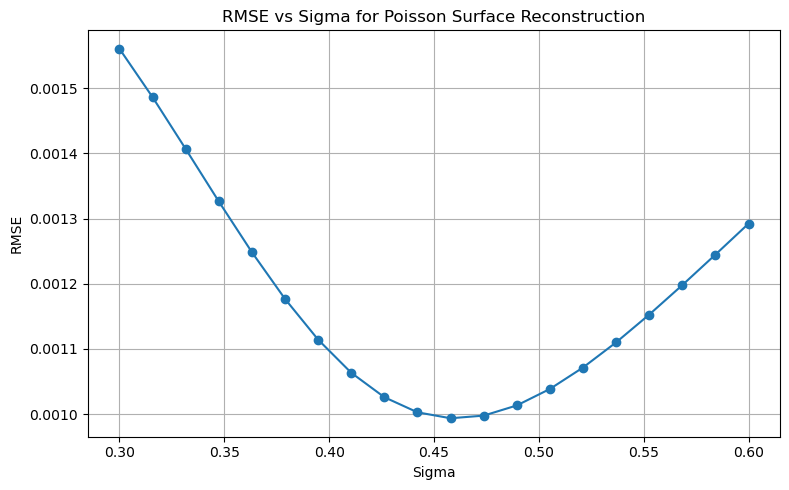

In [221]:

def calculate_rmse(reconstructed_points):

    radii = np.sqrt(
        reconstructed_points[:, 0]**2 +
        reconstructed_points[:, 1]**2
    )

    errors = radii - 1.0

    return np.sqrt(np.mean(errors**2))


def calculate_rmse_for_sigma( sigma, scan_points, scan_normals, grid_points, nx, ny, dx, dy, X, Y, D ):

    grid_vectors = calculate_vector_field( scan_points, scan_normals, grid_points, sigma, D )

    divergence = calculate_divergence( grid_vectors, nx, ny, dx, dy )

    chi = poisson_solver( divergence, nx, ny, dx, dy )

    chi_grid = chi.reshape(nx, ny)

    interpolator = RegularGridInterpolator( (x, y), chi_grid )

    chi_samples = interpolator(scan_points)

    iso_value = np.mean(chi_samples)

    contour = plt.contour(
        X,
        Y,
        chi_grid,
        levels=[iso_value]
    )

    segments = contour.allsegs[0]

    plt.close()

    if len(segments) == 0:
        return np.nan

    reconstructed_points = max(
        segments,
        key=len
    )

    rmse = calculate_rmse( reconstructed_points )

    return rmse

sigma_values = np.linspace(0.3, 0.6, 20)
rmse_values = []

for sigma in sigma_values:

    rmse = calculate_rmse_for_sigma( sigma, scan_points, scan_normals, grid_points, nx, ny, dx, dy, X, Y, D )

    rmse_values.append(rmse)

    print(
        f"sigma = {sigma:.3f}, "
        f"RMSE = {rmse:.6f}"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    sigma_values,
    rmse_values,
    marker='o',
    linestyle='-'
)

plt.xlabel("Sigma")
plt.ylabel("RMSE")
plt.title("RMSE vs Sigma for Poisson Surface Reconstruction")

plt.grid(True)
plt.tight_layout()

plt.show()

del_space = 0.100, RMSE = 0.010999
del_space = 0.105, RMSE = 0.010467
del_space = 0.110, RMSE = 0.011075
del_space = 0.115, RMSE = 0.010634
del_space = 0.120, RMSE = 0.010692
del_space = 0.125, RMSE = 0.010815
del_space = 0.130, RMSE = 0.010587
del_space = 0.135, RMSE = 0.010495
del_space = 0.140, RMSE = 0.011189
del_space = 0.145, RMSE = 0.010748
del_space = 0.151, RMSE = 0.010125
del_space = 0.156, RMSE = 0.010749
del_space = 0.161, RMSE = 0.011425
del_space = 0.166, RMSE = 0.011425
del_space = 0.171, RMSE = 0.010349
del_space = 0.176, RMSE = 0.010571
del_space = 0.181, RMSE = 0.010571
del_space = 0.186, RMSE = 0.010632
del_space = 0.191, RMSE = 0.011895
del_space = 0.196, RMSE = 0.011895
del_space = 0.201, RMSE = 0.011280
del_space = 0.206, RMSE = 0.011280
del_space = 0.211, RMSE = 0.010447
del_space = 0.216, RMSE = 0.010447
del_space = 0.221, RMSE = 0.010447
del_space = 0.226, RMSE = 0.011227
del_space = 0.231, RMSE = 0.011227
del_space = 0.236, RMSE = 0.012832
del_space = 0.241, R

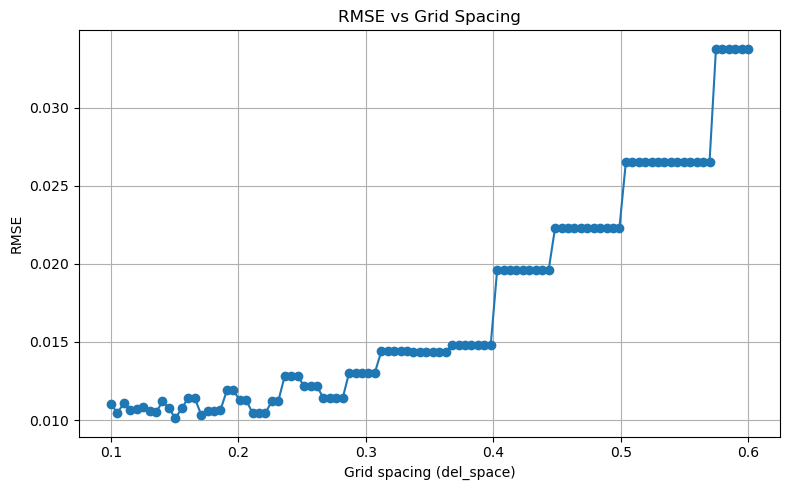

In [168]:
def calculate_rmse_for_del_space( del_space, scan_points, scan_normals, sigma, D, size=2):

    nx = int(2 * size / del_space) + 1
    ny = int(2 * size / del_space) + 1

    x = np.linspace(-size, size, nx)
    y = np.linspace(-size, size, ny)

    dx = x[1] - x[0]
    dy = y[1] - y[0]

    X, Y = np.meshgrid(x, y, indexing="ij")

    grid_points = np.column_stack(
        (X.ravel(), Y.ravel())
    )

    grid_vectors = calculate_vector_field( scan_points, scan_normals, grid_points, sigma, D )

    divergence = calculate_divergence( grid_vectors, nx, ny, dx, dy )

    chi = poisson_solver( divergence, nx, ny, dx, dy )

    chi_grid = chi.reshape(nx, ny)

    interpolator = RegularGridInterpolator( (x, y), chi_grid )

    chi_samples = interpolator(scan_points)

    iso_value = np.mean(chi_samples)

    contour = plt.contour(
        X,
        Y,
        chi_grid,
        levels=[iso_value]
    )

    segments = contour.allsegs[0]

    plt.close()

    if len(segments) == 0:
        return np.nan

    reconstructed_points = max(
        segments,
        key=len
    )

    rmse = calculate_rmse( reconstructed_points )

    return rmse

del_space_values = np.linspace(0.1, 0.6, 100)

sigma = 1.75
D = 100
size = 2

rmse_values = []

for del_space in del_space_values:

    rmse = calculate_rmse_for_del_space( del_space, scan_points, scan_normals, sigma, D, size )

    rmse_values.append(rmse)

    print(
        f"del_space = {del_space:.3f}, "
        f"RMSE = {rmse:.6f}"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    del_space_values,
    rmse_values,
    marker="o",
    linestyle="-"
)

plt.xlabel("Grid spacing (del_space)")
plt.ylabel("RMSE")
plt.title("RMSE vs Grid Spacing")

plt.grid(True)
plt.tight_layout()

plt.show()

D = 0.1, RMSE = 0.002448
D = 0.1285714285714286, RMSE = 0.002583
D = 0.15714285714285714, RMSE = 0.002126
D = 0.18571428571428572, RMSE = 0.001810
D = 0.2142857142857143, RMSE = 0.001723
D = 0.24285714285714288, RMSE = 0.001630
D = 0.27142857142857146, RMSE = 0.001587
D = 0.30000000000000004, RMSE = 0.001592
D = 0.3285714285714286, RMSE = 0.001596
D = 0.3571428571428572, RMSE = 0.001599
D = 0.3857142857142858, RMSE = 0.001600
D = 0.41428571428571437, RMSE = 0.001600
D = 0.44285714285714284, RMSE = 0.001600
D = 0.4714285714285714, RMSE = 0.001600
D = 0.5, RMSE = 0.001600


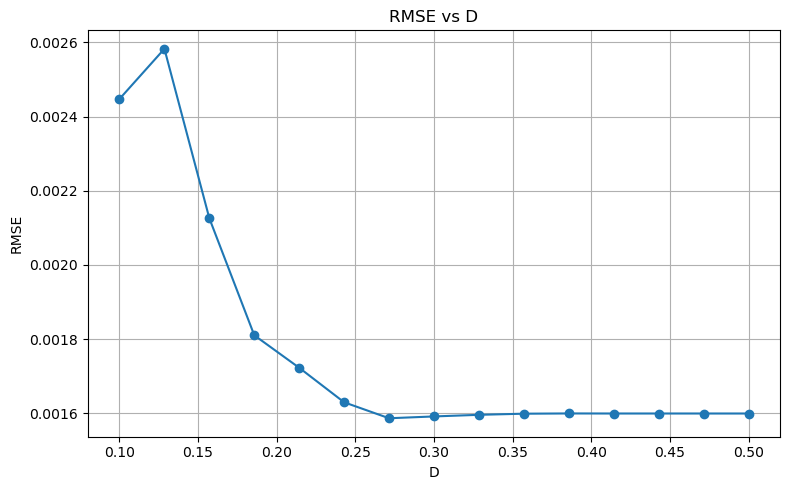

In [169]:

def calculate_rmse_for_D( D, scan_points, scan_normals, sigma, del_space, size=2 ):

    nx = int(2 * size / del_space) + 1
    ny = int(2 * size / del_space) + 1

    x = np.linspace(-size, size, nx)
    y = np.linspace(-size, size, ny)

    dx = x[1] - x[0]
    dy = y[1] - y[0]

    X, Y = np.meshgrid(x, y, indexing="ij")

    grid_points = np.column_stack(
        (X.ravel(), Y.ravel())
    )

    grid_vectors = calculate_vector_field( scan_points, scan_normals, grid_points, sigma, D )

    divergence = calculate_divergence( grid_vectors, nx, ny, dx, dy )

    chi = poisson_solver( divergence, nx, ny, dx, dy )

    chi_grid = chi.reshape(nx, ny)

    interpolator = RegularGridInterpolator(
        (x, y),
        chi_grid
    )

    chi_samples = interpolator(scan_points)

    iso_value = np.mean(chi_samples)

    contour = plt.contour(
        X,
        Y,
        chi_grid,
        levels=[iso_value]
    )

    segments = contour.allsegs[0]

    plt.close()

    if len(segments) == 0:
        return np.nan

    reconstructed_points = max(
        segments,
        key=len
    )

    return calculate_rmse(reconstructed_points)


D_values = np.linspace(0.1, 0.5, 15)

sigma = 0.1
del_space = 0.04

rmse_values = []

for D in D_values:

    rmse = calculate_rmse_for_D( D, scan_points, scan_normals, sigma, del_space )

    rmse_values.append(rmse)

    print(
        f"D = {D}, RMSE = {rmse:.6f}"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    D_values,
    rmse_values,
    marker="o",
    linestyle="-"
)

plt.xlabel("D")
plt.ylabel("RMSE")
plt.title("RMSE vs D")

plt.grid(True)
plt.tight_layout()

plt.show()